## Note:

If you don't know how to use Jupyter notebooks, you can find a tutorial here: https://www.dataquest.io/blog/jupyter-notebook-tutorial/

You'll need few libraries to run this notebook. If you don't have them, you can install them (preferably in a virtual environment).

To know more about virtual environments, you can read this: https://docs.python.org/3/tutorial/venv.html

You can also use anaconda to create a virtual environment. To know more about anaconda, you can read this: https://docs.anaconda.com/anaconda/user-guide/getting-started/

You can also google other ways to create virtual environments.

We use the following libraries in this notebook, so make sure you have them installed:

- numpy

- sklearn

- spacy

Significant part of the notebook is about data preparation, where you are not expected to write any code. You have to run the code cells (in sequence), read the comments, and understand the process. Towards the end of the notebook, you'll be asked to write some code and do some experiments.

For better understanding, copy this notebook separately (different from the one you submit) and play around with the code: you can change the code, print the values, and see the effects (but you don't need to submit that).

## Submission Details
**Please fill out the following information.**

Group Number: 31

Members: Niklas Fritz

## So... how does a language dataset look like?
Let's import the 20 newsgroups dataset from sklearn and take a look at it.

In [1]:
# load the package
from sklearn.datasets import fetch_20newsgroups
# fetch the data
data = fetch_20newsgroups(subset='train')['data']

Our real data looks like below:

In [2]:
print(data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







Pretty good right? NO.
It is your browser making it look good. Let's see what it looks like in the raw format (which the machine will process in the end).

In [3]:
print(repr(data[0]))

"From: lerxst@wam.umd.edu (where's my thing)\nSubject: WHAT car is this!?\nNntp-Posting-Host: rac3.wam.umd.edu\nOrganization: University of Maryland, College Park\nLines: 15\n\n I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.\n\nThanks,\n- IL\n   ---- brought to you by your neighborhood Lerxst ----\n\n\n\n\n"


OH NO.... This is **not good**.

Why though?

You see, we might still be able to understand the above text.
But, we can agree that there is a lot of noise in the text.

First, let's remove headers and footers, since they are not useful for most of the NLP tasks.

How do we remove it? Know your data **patterns**.
If we look at the text carefully the body of the email is between two '\n\n' characters.
Let's split through that.

In [4]:
first_doc = data[0].split('\n\n')
print(first_doc)
print(len(first_doc))

["From: lerxst@wam.umd.edu (where's my thing)\nSubject: WHAT car is this!?\nNntp-Posting-Host: rac3.wam.umd.edu\nOrganization: University of Maryland, College Park\nLines: 15", ' I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.', 'Thanks,\n- IL\n   ---- brought to you by your neighborhood Lerxst ----', '', '\n']
5


So.. the body of the email is now in the second element of the list.

In [5]:
first_doc = first_doc[1]
print(repr(first_doc))

' I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.'


All good now? NO.

We have got the main content of the fiirst email. But, it is still not good enough. There are still a lot of noise in the text.

Now, should we split again? NO. There is no clear pattern in the text.

Should we remove '\n' directly from the string. NO. Your 'saw\nthe' will become 'sawthe'. We don't want that (since it's not a proper word).

Hmm.. this is a tough one. Let's think about it...

Tokenization is the answer. Rather, a smart tokenization.

In [6]:
# let's use spaCy to tokenize the document
from spacy.lang.en import English
nlp = English()
# Create a Tokenizer with the default settings for English
# including punctuation rules and exceptions
tokenizer = nlp.tokenizer
# We can now use the tokenizer to tokenize our document
first_doc = [token.text for token in tokenizer(first_doc)]

In [7]:
print(first_doc)

[' ', 'I', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'I', 'saw', '\n', 'the', 'other', 'day', '.', 'It', 'was', 'a', '2', '-', 'door', 'sports', 'car', ',', 'looked', 'to', 'be', 'from', 'the', 'late', '60s/', '\n', 'early', '70s', '.', 'It', 'was', 'called', 'a', 'Bricklin', '.', 'The', 'doors', 'were', 'really', 'small', '.', 'In', 'addition', ',', '\n', 'the', 'front', 'bumper', 'was', 'separate', 'from', 'the', 'rest', 'of', 'the', 'body', '.', 'This', 'is', '\n', 'all', 'I', 'know', '.', 'If', 'anyone', 'can', 'tellme', 'a', 'model', 'name', ',', 'engine', 'specs', ',', 'years', '\n', 'of', 'production', ',', 'where', 'this', 'car', 'is', 'made', ',', 'history', ',', 'or', 'whatever', 'info', 'you', '\n', 'have', 'on', 'this', 'funky', 'looking', 'car', ',', 'please', 'e', '-', 'mail', '.']


Perfect. Now you can:
- Easily read the text
- Tokens (words) are separated by spaces and no other complicated pattern.
- You can easily remove stopwords, punctuations, special characters, etc.

> ## What is a token?
> A token is a single entity that is building block of a sentence. It can be a word, a punctuation, a number, etc.

Always remember, **tokenization is the first step in any NLP task**.
Your text should *look* like the above version before you start any NLP task. We don't want to deal with the noise in the text.

Amazing! Now, we have a clean text in a list. If you want to get it back in string format:

In [8]:
first_doc = ' '.join(first_doc)

In [9]:
print(repr(first_doc))

'  I was wondering if anyone out there could enlighten me on this car I saw \n the other day . It was a 2 - door sports car , looked to be from the late 60s/ \n early 70s . It was called a Bricklin . The doors were really small . In addition , \n the front bumper was separate from the rest of the body . This is \n all I know . If anyone can tellme a model name , engine specs , years \n of production , where this car is made , history , or whatever info you \n have on this funky looking car , please e - mail .'


## Let's do some preprocessing and build vocabulary

In [10]:
# let's import the whole dataset. we will also remove the headers and footers from the emails.
data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))['data']
labels = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))['target']

In [11]:
# let's use spaCy to tokenize all the documents
data = [[token.text.lower() for token in tokenizer(doc)] for doc in data]
#list of lists where each inner list is a tokenized document
#token.text.lower() to convert every word to lowercase

In [12]:
print(data[0])

['i', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'i', 'saw', '\n', 'the', 'other', 'day', '.', 'it', 'was', 'a', '2', '-', 'door', 'sports', 'car', ',', 'looked', 'to', 'be', 'from', 'the', 'late', '60s/', '\n', 'early', '70s', '.', 'it', 'was', 'called', 'a', 'bricklin', '.', 'the', 'doors', 'were', 'really', 'small', '.', 'in', 'addition', ',', '\n', 'the', 'front', 'bumper', 'was', 'separate', 'from', 'the', 'rest', 'of', 'the', 'body', '.', 'this', 'is', '\n', 'all', 'i', 'know', '.', 'if', 'anyone', 'can', 'tellme', 'a', 'model', 'name', ',', 'engine', 'specs', ',', 'years', '\n', 'of', 'production', ',', 'where', 'this', 'car', 'is', 'made', ',', 'history', ',', 'or', 'whatever', 'info', 'you', '\n', 'have', 'on', 'this', 'funky', 'looking', 'car', ',', 'please', 'e', '-', 'mail', '.']


> ## What is a vocabulary?
> A vocabulary is a set of all the unique words in the text.

In [13]:
def calculate_vocab(data):
    # let's build a vocabulary of words from the data using dictionary
    # key is the word and value is the frequency of the word
    vocab = {}
    for doc in data:
        for token in doc:
            if token not in vocab:
                vocab[token] = 1
            else:
                vocab[token] += 1
    # also let's sort the vocabulary in descending order of frequency (to see the most frequent words)
    vocab = sorted(vocab.items(), key=lambda x: x[1], reverse=True)
    return vocab

vocab = calculate_vocab(data)

Now there are three things that can interest us:

1. Which words are most frequent in the text?

2. Which words are least frequent in the text?

3. Are there any special/weird words in the text?

Top 30 most frequent words in the text:

In [14]:
vocab[:30]

[('\n', 150431),
 ('the', 106381),
 (',', 104949),
 ('.', 101963),
 (' ', 55526),
 ('to', 53047),
 ('of', 46929),
 ('a', 43165),
 ('and', 42526),
 ('i', 34066),
 ('in', 31045),
 ('-', 31027),
 ('is', 31006),
 ('that', 28029),
 ('\n\n', 27790),
 ('=', 27332),
 (')', 26697),
 ('"', 24772),
 ('(', 24675),
 ('it', 23619),
 (':', 21691),
 ('for', 19962),
 ('*', 19876),
 ('you', 18357),
 ('_', 16925),
 ('?', 14979),
 ('this', 14480),
 ('on', 14442),
 ('be', 13785),
 ('>', 13505)]

30 words with frequency 1:

In [15]:
[token for token, count in vocab if count == 1][0:30]
#list of elements in vocab where the tuple (token, count) has count equal to 1

['60s/',
 'tellme',
 'introductions',
 '185c',
 'twillis@ecn.purdue.edu',
 'c5owcb.n3p@world.std.com',
 'tombaker@world.std.com',
 'astrocytomas',
 'debra',
 '                                                                      \n',
 'compare[version',
 'inconsiant',
 'ansynchronous',
 '-brando',
 'stinky',
 '900gts',
 '17k',
 '3495',
 '3k.',
 'sadducees',
 '->talmud',
 'unashamedly',
 'comtemporary',
 'i`m',
 'relevation',
 'subjectiveness',
 'disobeys',
 'piaget',
 'srt',
 'gn&c']

Length of the vocabulary:

In [16]:
print(len(vocab))

116059


Observations:
- There are word which occur too many times. They are syntactic words. They don't add any meaning to the text but are used to make the text grammatically correct. Stopwords are such words.
- There are words which occur only once. They are rare words. They are also called as **out of vocabulary** words.
- Our vocabulary is 116059 words long for 1000 documents. That's a lot of words. We can't use all of them. We need to reduce the vocabulary size.

If you look at the vocabulary carefully, there are a lot of *weird* words. They are present because data sometimes is not scrapped properly. We need to deal with them. Here we will use some specialized tokens to deal with them.

The plan is simple:
- Replace all the numbers with a special token 'NUM' (because having 1000 different tokens for 1000 different numbers is not a good idea)
- Replace all the alphanumeric words with a special token 'ALPHANUM' (same reason as above)
- If it is an legal alphabetical word, then we will keep it as it is.
- If it is a punctuation, then we will keep it as it is.
- If it is anything else, then we will replace it with a special token 'UNK' (anything else other than the above mostly isn't useful to us)

Note that this is one of the many ways to deal with the weird words. Sometimes you will need to think task specific. For example, if you are building a chatbot, then you might want to keep the emoticons as it is.

In [17]:
all_punctuations = '''!()-[]{};:'"\,<>./?@#$%^&*_~'''
all_punctuations = [token for token in all_punctuations]
print(all_punctuations)

['!', '(', ')', '-', '[', ']', '{', '}', ';', ':', "'", '"', '\\', ',', '<', '>', '.', '/', '?', '@', '#', '$', '%', '^', '&', '*', '_', '~']


In [18]:
for i, doc in enumerate(data):
    for j, token in enumerate(doc):
        # legal alphabetic tokens
        if token.isalpha():
            doc[j] = token
        # replace numbers with <NUM>
        elif token.isnumeric():
            doc[j] = '<NUM>'
        # replace alphanumeric tokens with <ALPHANUM>
        elif token.isalnum():
            doc[j] = '<ALPHANUM>'
        # if punctuation
        elif token in all_punctuations:
            doc[j] = token
        # anything else, replace with <UNK>
        else:
            doc[j] = '<UNK>'
#run through list of tokens of each document and replace special tokens

In [19]:
print(data[0])

['i', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'i', 'saw', '<UNK>', 'the', 'other', 'day', '.', 'it', 'was', 'a', '<NUM>', '-', 'door', 'sports', 'car', ',', 'looked', 'to', 'be', 'from', 'the', 'late', '<UNK>', '<UNK>', 'early', '<ALPHANUM>', '.', 'it', 'was', 'called', 'a', 'bricklin', '.', 'the', 'doors', 'were', 'really', 'small', '.', 'in', 'addition', ',', '<UNK>', 'the', 'front', 'bumper', 'was', 'separate', 'from', 'the', 'rest', 'of', 'the', 'body', '.', 'this', 'is', '<UNK>', 'all', 'i', 'know', '.', 'if', 'anyone', 'can', 'tellme', 'a', 'model', 'name', ',', 'engine', 'specs', ',', 'years', '<UNK>', 'of', 'production', ',', 'where', 'this', 'car', 'is', 'made', ',', 'history', ',', 'or', 'whatever', 'info', 'you', '<UNK>', 'have', 'on', 'this', 'funky', 'looking', 'car', ',', 'please', 'e', '-', 'mail', '.']


Is vocabulary size reduced?

In [20]:
vocab = calculate_vocab(data)
print(len(vocab))

57726


This is a significant reduction in vocabulary size. Let's see the top 30 most frequent words now:

In [21]:
vocab[:30]

[('<UNK>', 492164),
 ('the', 106381),
 (',', 104949),
 ('.', 101963),
 ('<NUM>', 59697),
 ('to', 53047),
 ('of', 46929),
 ('a', 43165),
 ('and', 42526),
 ('i', 34066),
 ('in', 31045),
 ('-', 31027),
 ('is', 31006),
 ('that', 28029),
 (')', 26697),
 ('"', 24772),
 ('(', 24675),
 ('it', 23619),
 (':', 21691),
 ('for', 19962),
 ('*', 19876),
 ('you', 18357),
 ('_', 16925),
 ('?', 14979),
 ('this', 14480),
 ('on', 14442),
 ('be', 13785),
 ('>', 13505),
 ('are', 13341),
 ('have', 13170)]

And the words with frequency 1:

In [22]:
[token for token, count in vocab if count == 1][0:30]

['tellme',
 'introductions',
 'astrocytomas',
 'debra',
 'inconsiant',
 'ansynchronous',
 'stinky',
 'sadducees',
 'unashamedly',
 'comtemporary',
 'relevation',
 'subjectiveness',
 'disobeys',
 'piaget',
 'srt',
 'vehilce',
 'habitability',
 'internationals',
 'dreamt',
 'decut',
 'thunderbird',
 'munny',
 'unforgiven',
 'subcompact',
 'anisetti',
 'finaly',
 'thermocouple',
 'thermocouples',
 'olcyzk',
 'tists']

Observations:
- The vocabulary size is reduced to 57726 words from 116059 words. That's a good reduction.
- There are almost no weird words now. The words with frequency 1 are now mostly spelling mistakes, rare words, bad scrapping, etc.
- we can do one final thing: either give special tokens to these rare words or remove them. We will remove them and check the vocabulary size.

In [23]:
print(len([vocab[i] for i in range(len(vocab)) if vocab[i][1] > 5]))

15985


Very nice. Now the vocabulary of the whole data is just 15985 words, reduced from 116059 words. That's a huge reduction. By just cleaning the data

Maybe let's give rare words a special token: RARE

In [24]:
vocab = [token for token, count in vocab if count > 5]
for i, doc in enumerate(data):
    for j, token in enumerate(doc):
        if token not in vocab:
            doc[j] = '<RARE>'

Again, validate the vocabulary size:

In [25]:
vocab = calculate_vocab(data)
print(len(vocab))

15986


In [26]:
print(data[0])

['i', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'i', 'saw', '<UNK>', 'the', 'other', 'day', '.', 'it', 'was', 'a', '<NUM>', '-', 'door', 'sports', 'car', ',', 'looked', 'to', 'be', 'from', 'the', 'late', '<UNK>', '<UNK>', 'early', '<ALPHANUM>', '.', 'it', 'was', 'called', 'a', '<RARE>', '.', 'the', 'doors', 'were', 'really', 'small', '.', 'in', 'addition', ',', '<UNK>', 'the', 'front', 'bumper', 'was', 'separate', 'from', 'the', 'rest', 'of', 'the', 'body', '.', 'this', 'is', '<UNK>', 'all', 'i', 'know', '.', 'if', 'anyone', 'can', '<RARE>', 'a', 'model', 'name', ',', 'engine', 'specs', ',', 'years', '<UNK>', 'of', 'production', ',', 'where', 'this', 'car', 'is', 'made', ',', 'history', ',', 'or', 'whatever', 'info', 'you', '<UNK>', 'have', 'on', 'this', 'funky', 'looking', 'car', ',', 'please', 'e', '-', 'mail', '.']


## How do we represent text as numbers?

Two ways:
- Bag of words
- Sequence of words

### Bag of words

> ## Where do we use bag of words?
> We use bag of words when we don't care about the order of the words for modeling. For example in Multi Layer Perceptron (MLP) models, we use bag of words.

In [27]:
import numpy as np

In [28]:
# docs to bag of words
def docs_to_bow(data, vocab):
    # initialize the bag of words
    bow = np.zeros((len(data), len(vocab)), dtype=np.int32)
    for i, doc in enumerate(data):
        for token in doc:
            bow[i][vocab[token]] += 1
    return bow

In [29]:
# vocab to dictionary
vocab = {token: i for i, (token, count) in enumerate(vocab)}
import random
random.seed(42)
vocab = list(vocab.items())
random.shuffle(vocab)
vocab = {token: i for i, (token, count) in enumerate(vocab)}

In [30]:
bow_docs = docs_to_bow(data, vocab)

In [31]:
bow_docs.shape
#number of docs cross vocab size
#bow_docs[i,j] = number of times word j appears in document i

(11314, 15986)

How does a BoW look like?

In [32]:
print(bow_docs[0].tolist())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

This is how a BoW looks like. It is a vector of size vocabulary size. Each element in the vector represents the frequency of the word in the text.

Words appearing in the first document:

In [33]:
print(np.array(list(vocab.keys()))[bow_docs[0]>0])

['on' 'i' 'you' 'there' 'were' 'called' 'model' 'made' 'rest' '<NUM>'
 'where' 'front' 'e' '<UNK>' 'car' 'specs' '-' 'could' 'late' 'all' 'mail'
 'me' 'funky' 'a' 'name' 'wondering' 'whatever' '<ALPHANUM>' 'small'
 'bumper' 'years' 'door' 'anyone' 'day' 'if' 'was' 'have' 'of' 'is'
 'separate' '.' 'the' '<RARE>' 'know' 'info' 'other' 'sports' 'early' ','
 'enlighten' 'in' 'out' 'history' 'please' 'saw' 'doors' 'production'
 'body' 'this' 'engine' 'can' 'addition' 'looked' 'it' 'from' 'looking'
 'to' 'be' 'really' 'or']


In [34]:
print(data[0])

['i', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'i', 'saw', '<UNK>', 'the', 'other', 'day', '.', 'it', 'was', 'a', '<NUM>', '-', 'door', 'sports', 'car', ',', 'looked', 'to', 'be', 'from', 'the', 'late', '<UNK>', '<UNK>', 'early', '<ALPHANUM>', '.', 'it', 'was', 'called', 'a', '<RARE>', '.', 'the', 'doors', 'were', 'really', 'small', '.', 'in', 'addition', ',', '<UNK>', 'the', 'front', 'bumper', 'was', 'separate', 'from', 'the', 'rest', 'of', 'the', 'body', '.', 'this', 'is', '<UNK>', 'all', 'i', 'know', '.', 'if', 'anyone', 'can', '<RARE>', 'a', 'model', 'name', ',', 'engine', 'specs', ',', 'years', '<UNK>', 'of', 'production', ',', 'where', 'this', 'car', 'is', 'made', ',', 'history', ',', 'or', 'whatever', 'info', 'you', '<UNK>', 'have', 'on', 'this', 'funky', 'looking', 'car', ',', 'please', 'e', '-', 'mail', '.']


### Sequence of words

> ## Where do we use sequence of words?
> We use sequence of words when we care about the order of the words for modeling (sequential models). For example in Recurrent Neural Networks (RNN) models, Transformers, etc. we use sequence of words.

We already have sequence of words. But we need to convert it to numbers. How do we do that?
Replace each word with its index in the vocabulary.

In [35]:
document_tokens = [[vocab[token] for token in doc] for doc in data]
#vocab[token] gives the index of the token in the vocab

This is how a sequence of words looks like. It is a vector of size equal to the number of words in the text. Each element in the vector represents the index of the word in the vocabulary.

In [36]:
print(document_tokens[0])

[1654, 7888, 5753, 7715, 7223, 11917, 1873, 4634, 11617, 5326, 10, 13437, 4240, 1654, 12905, 4109, 9389, 10012, 7248, 9104, 14571, 7888, 5402, 3403, 4420, 7124, 10080, 4240, 10392, 14565, 15236, 15285, 14698, 9389, 5025, 4109, 4109, 10218, 6207, 9104, 14571, 7888, 2797, 5402, 9699, 9104, 9389, 13000, 2377, 15416, 6272, 9104, 11682, 14140, 10392, 4109, 9389, 3831, 6313, 7888, 8559, 14698, 9389, 3339, 8159, 9389, 13279, 9104, 13437, 8407, 4109, 5074, 1654, 9785, 9104, 7715, 7223, 14103, 9699, 5402, 2847, 5464, 10392, 14080, 4295, 10392, 6766, 4109, 8159, 13199, 10392, 3710, 13437, 4240, 8407, 2978, 10392, 11924, 10392, 15583, 6029, 9875, 1805, 4109, 8147, 10, 13437, 5337, 15000, 4240, 10392, 12753, 4056, 4420, 5224, 9104]


Let's convert it to a numpy array (for easy manipulation):

In [37]:
np.array(document_tokens)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (11314,) + inhomogeneous part.

Uh! Oh, we have a problem. The length of the sequence is different for each document. We need to make it of same length. How do we do that?

We can pad the sequence with a special token 'PAD' to make it of same length.

In [38]:
# one can use the max length of the documents as the length of the documents, but we will use 100 for simplicity
# max_length = max([len(doc) for doc in document_tokens])
max_length = 500
vocab_size = len(vocab)
vocab['<PAD>'] = vocab_size #adding padding token with last index to the vocab
# pad the documents
padded_docs = []
for doc in document_tokens:
    if len(doc) < max_length:
        padded_docs.append(doc + [vocab['<PAD>']]*(max_length-len(doc)))
    else:
        padded_docs.append(doc[:max_length])

In [39]:
print(padded_docs[5])

[4109, 8159, 978, 9104, 4109, 9389, 10869, 1551, 15285, 9699, 14223, 11682, 10622, 14267, 9104, 4109, 1654, 13153, 1586, 7997, 13437, 10869, 11075, 3445, 9104, 4109, 1805, 11110, 8021, 5402, 4092, 13746, 4109, 14698, 5854, 10392, 14103, 1805, 12260, 14571, 692, 3781, 4109, 1654, 11559, 9389, 7840, 4490, 1116, 7036, 6174, 15968, 4786, 5228, 8159, 7311, 4109, 8092, 11653, 4490, 9995, 2109, 2731, 15745, 7340, 5613, 15236, 10012, 9365, 9104, 4109, 9389, 7036, 6145, 13837, 7888, 15236, 8050, 3445, 2640, 5074, 5228, 781, 15285, 4109, 6271, 10392, 15745, 7340, 9389, 1909, 4289, 7888, 10392, 6988, 13437, 12596, 10392, 15236, 4109, 11298, 7367, 6769, 9104, 4109, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15986, 15

The 15986 is the index of the token 'PAD' in the vocabulary. And hence is repeated in the sequence to make it of same length as other sequences.

Let's convert it to a numpy array now:

In [40]:
padded_docs = np.array(padded_docs)

It works now. You will need to do this when working with numpy or pytorch. Pad your data to make it of same length.

In [41]:
# let's convert the first document back to text
print(' '.join([list(vocab.keys())[token] for token in padded_docs[0]]))

i was wondering if anyone out there could enlighten me on this car i saw <UNK> the other day . it was a <NUM> - door sports car , looked to be from the late <UNK> <UNK> early <ALPHANUM> . it was called a <RARE> . the doors were really small . in addition , <UNK> the front bumper was separate from the rest of the body . this is <UNK> all i know . if anyone can <RARE> a model name , engine specs , years <UNK> of production , where this car is made , history , or whatever info you <UNK> have on this funky looking car , please e - mail . <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD

Perfect. Now we have a sequence of words for each document. We can use this to train a sequential model.

Usually they need embeddings as well. We will see that in some other tutorial.

## Let's build a simple model to classify the emails

Now we are going to see that how we can use the data we have prepared to train a simple model to classify the emails.

We will use the bag of words representation of the text to train a simple Neural Network model.

Read more about the model from: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

Our aim is to see how our accuracy changes when we use different preprocessing techniques.

In [42]:
# import model
from sklearn.neural_network import MLPClassifier
# divide the data into train and test
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(bow_docs, labels, test_size=0.2, random_state=42)

Let's first try without any preprocessing:

In [43]:
# First let's see how our data looks like
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9051, 15986), (2263, 15986), (9051,), (2263,))

In the above shape the first number is the number of documents in the training set and the second number is the vocabulary size.

In the label y it's a class of the email.

In [44]:
# how many classes do we have?
print(len(set(labels)))

20


In [45]:
def classifier(X_train, y_train, X_test, y_test):
    # initialize the classifier
    clf = MLPClassifier(random_state=42, max_iter=10)
    # train the classifier
    clf.fit(X_train, y_train)
    # predict the labels for the test data
    y_pred = clf.predict(X_test)
    # calculate the accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [46]:
# let's train a simple neural network (defined above) on the bag of words
accuracy = classifier(X_train, y_train, X_test, y_test)
print(accuracy)

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


0.728678745028723


So we got about ~ 0.73 (73%) accuracy. That's not THAT bad considering there are 20 classes. Let's try with some preprocessing now.
Do note that we didn't train the model till convergence. We just wanted to see how the accuracy changes with different preprocessing techniques.

## Your Tasks:
Do not change the code above. Just add the code below for your tasks.

(for computing accuracy use the classifier function defined above).
- Remove stopwords and special tokens from the text (BoW) and see how the accuracy changes. (Hint: list of stopwords and special tokens are given below, also just delete the columns from the BoW matrices (X_train) and (X_test) which correspond to the stopwords and special tokens)
- Apply tf-idf and see how the accuracy changes. (You have to apply this manually. Don't use packages)
- Find and report the minimal sufficient vocabulary size based on the accuracy. (report both vocab size and accuracy)

In [47]:
# spacy stop words
from spacy.lang.en.stop_words import STOP_WORDS
STOP_WORDS = list(STOP_WORDS) + ['<NUM>', '<ALPHANUM>', '<UNK>', '<RARE>'] + all_punctuations
vocab.pop('<PAD>')
print(STOP_WORDS)

['he', 'these', 'amount', 'than', 'of', 'former', 'well', 'whom', 'anyway', 'nowhere', 'something', 'all', 'being', 'seem', 'onto', 'our', 'often', 'five', 'she', 'eight', 'am', 'make', 'is', 'eleven', 'its', "'m", 'empty', 'formerly', 'my', 'next', 'cannot', 'on', 'through', 'nevertheless', 'although', 'your', 'used', 'becomes', 'done', 'moreover', 'else', 'name', 'whereby', 'because', 'you', 'thereby', 'whatever', 'another', 'against', 'most', 'third', 'yourselves', 'hers', 'after', 'serious', 'everyone', 'move', 'sometime', 'wherein', '’d', 'only', '‘ve', 'six', "n't", 'here', '‘d', 'and', 'four', 'then', 'three', 'itself', 'thence', 'beside', '‘s', 'before', 'them', 'those', 'less', 'below', 'behind', 'part', 'upon', 'as', 'becoming', 'very', 'say', 'may', 'with', 'meanwhile', 'just', 'via', 'ever', 'anyone', 'throughout', 'wherever', 'i', 'are', 'hereupon', 'why', 'back', 'really', 'him', 'who', 'anyhow', 'when', 'nor', 'side', 'without', 'call', 'they', 'her', 'nobody', 'everythi

In [48]:
index_of_stopwords = []
print(STOP_WORDS)
for i in STOP_WORDS:
    if i in vocab:
        index_of_stopwords.append(vocab[i])

['he', 'these', 'amount', 'than', 'of', 'former', 'well', 'whom', 'anyway', 'nowhere', 'something', 'all', 'being', 'seem', 'onto', 'our', 'often', 'five', 'she', 'eight', 'am', 'make', 'is', 'eleven', 'its', "'m", 'empty', 'formerly', 'my', 'next', 'cannot', 'on', 'through', 'nevertheless', 'although', 'your', 'used', 'becomes', 'done', 'moreover', 'else', 'name', 'whereby', 'because', 'you', 'thereby', 'whatever', 'another', 'against', 'most', 'third', 'yourselves', 'hers', 'after', 'serious', 'everyone', 'move', 'sometime', 'wherein', '’d', 'only', '‘ve', 'six', "n't", 'here', '‘d', 'and', 'four', 'then', 'three', 'itself', 'thence', 'beside', '‘s', 'before', 'them', 'those', 'less', 'below', 'behind', 'part', 'upon', 'as', 'becoming', 'very', 'say', 'may', 'with', 'meanwhile', 'just', 'via', 'ever', 'anyone', 'throughout', 'wherever', 'i', 'are', 'hereupon', 'why', 'back', 'really', 'him', 'who', 'anyhow', 'when', 'nor', 'side', 'without', 'call', 'they', 'her', 'nobody', 'everythi

Let's delete the corresponding columns in the BoW matrices

In [49]:
print(X_train.shape)
print(X_test.shape)
X_train_new = np.delete(X_train, index_of_stopwords, axis=1)
X_test_new = np.delete(X_test, index_of_stopwords, axis=1)
print("New sizes of the BoW represeantaion:")
print(X_train_new.shape)
print(X_test_new.shape)

(9051, 15986)
(2263, 15986)
New sizes of the BoW represeantaion:
(9051, 15659)
(2263, 15659)


Now we can apply the TF-IDF 

As I received runtime Warnings I ensured to avoid dividing by zero

I read about how to fit models for TF-IDF and ibserved that the IDF values are taken from the train data as well in the test stage. When predicting a new document, we use the IDF trained by test dat and compute the Term frequency for the document to predict.

In [51]:
#BoW hat documents in rows and tokens in columns
def apply_tfidf(X_train, X_test):
    """
    Berechnet TF-IDF manuell für gegebene BoW-Matrizen.
    """

    #Compute IDF(t) for each term t in the vocabulary
    number_documents = X_train.shape[0]
    number_of_doc_t_appears = np.count_nonzero(X_train > 0, axis=0)
    idf = np.log(number_documents / np.maximum(1, number_of_doc_t_appears)) #avoid dividing by zero?!

    #Compute TF(t,d)
    frequency_t_in_d = X_train
    number_of_terms_in_d = np.sum(X_train, axis=1, keepdims=True)
    number_of_terms_in_d[number_of_terms_in_d == 0] = 1 #avoid dividing by zero

    tf = frequency_t_in_d / number_of_terms_in_d

    #Compute TF-IDF(t,d) = TF(t,d) * IDF(t)
    X_train_tfidf = tf * idf

    #Apply the same transformation to the test set
    #Compute TF(t,d)
    frequency_t_in_d = X_test
    number_of_terms_in_d = np.sum(X_test, axis=1, keepdims=True)
    number_of_terms_in_d[number_of_terms_in_d == 0] = 1 #avoid dividing by zero

    tf = frequency_t_in_d / number_of_terms_in_d

    #Compute TF-IDF(t,d) = TF(t,d) * IDF(t)
    X_test_tfidf = tf * idf

    return X_train_tfidf, X_test_tfidf

X_train_tfidf, X_test_tfidf = apply_tfidf(X_train_new, X_test_new)
accuracy_tfidf = classifier(X_train_tfidf, y_train, X_test_tfidf, y_test)
print(accuracy_tfidf)


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


0.7697746354396818


Next I want to find the minimal needed size vocabulary to get acceptable accuracy. Therefor I try to use the most important tokens. To simplify I assume these are the tokens, which appear most common. 

So I will compute how often a token (one of the reduced vocab version) appears and take the $K$ most frequent words as the top $K$ vocabs.

If you try to test implementation, you can expect around 12 min running time

In [53]:
import time

def top_k_indices(sorted_indices, k):
    return sorted_indices[::-1][:k] 

token_scores = X_train.sum(axis=0)
sorted_indices = np.argsort(token_scores)

accuracies_top_k = {}
time_top_k = {}

TD_IDF = True
for K in range(100, X_train.shape[1], 1000):
    top_k_idx = top_k_indices(sorted_indices, K)
    X_train_reduced = X_train[:, top_k_idx]
    X_test_reduced = X_test[:, top_k_idx]
    if TD_IDF == True:
        X_train_reduced, X_test_reduced = apply_tfidf(X_train_reduced, X_test_reduced)
    start_time = time.time()
    accuracy_reduced = classifier(X_train_reduced, y_train, X_test_reduced, y_test)
    end_time = time.time()
    time_top_k[K] = end_time - start_time
    print(f"Accuracy with top {K} tokens: {accuracy_reduced}")
    accuracies_top_k[K] = accuracy_reduced



c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy with top 100 tokens: 0.18692001767565178


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy with top 1100 tokens: 0.5395492708793637


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Accuracy with top 13100 tokens: 0.7441449403446753


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy with top 14100 tokens: 0.7467962881131242


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy with top 15100 tokens: 0.7534246575342466


Now I try to visualize to get balanced model

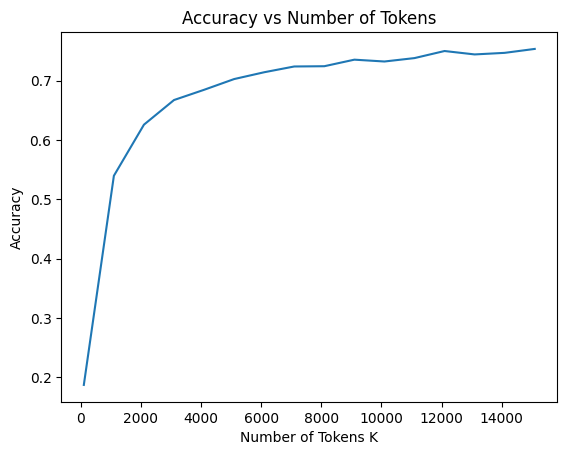

Text(0, 0.5, 'Time (s)')

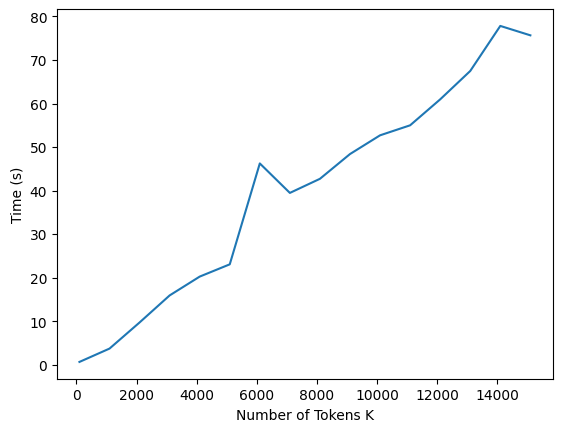

In [57]:
import matplotlib.pyplot as plt
Ks = range(100, X_train.shape[1], 1000)
plt.plot(Ks, [accuracies_top_k[K] for K in Ks])
plt.xlabel('Number of Tokens K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Tokens')
plt.show()
plt.plot(Ks, [time_top_k[K] for K in Ks])
plt.xlabel('Number of Tokens K')
plt.ylabel("Time (s)")

After reaching top 7000 tokens, the accuracy does not improve significantly anymore. Wen would need to invest much more token and time to get small improvements in accuracy. 

As one is interested in small model I would choose the top 7000 tokens as vocabulary. We just get 71 percent of accuracy.